# Final negative-augmentation step — merges the corrected caries dataset (Tratado_2 output) with a stratified, quality-filtered, group-split sample of external caries-free images (Chaudhary et al.). Generates the final detection dataset (Dataset Tratado 3) reported in article Table 7/Table 8.

Quality filtering is applied to the full pool of healthy-teeth images before sampling (not to a small pre-sampled subset), so the sharpness threshold is calibrated on the same-domain distribution.

It reads the caries dataset, which has ALREADY been repartitioned into groups and cleaned of
invalid boxes (`dataset_caries_corrected`, generated by
`Tratado_2_dataset_Ahmed.ipynb`), and merges it with a balanced sample
from the public dataset of healthy teeth (Chaudhary et al., 2024).

Confirmed actual results from the corrected caries dataset:
- 702 identifiers in train / 151 in val / 151 in test — 0 matches
  across partitions (no information leakage).
- 22 invalid bounding boxes excluded (0.54% of the original total).
- Final dataset: 1,262 images, 4,051 valid bounding boxes, 26 negative examples already
  present (train 880/2,865/20, val 184/566/2, test 198/620/4).

## 0. Setup and imports

In [ ]:
import os
import re
import json
import shutil
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES")

HEALTHY_ROOT = BASE / "Teeth or Dental Image Dataset"

CARIES_ROOT_CORREGIDO = BASE / "Dataset Tratado 2"

OUTPUT_ROOT_DRIVE = BASE / "Dataset Tratado 3"

QUALITY_CACHE_PATH = BASE / "healthy_pool_quality_cache.csv"

RUNTIME_ROOT = Path("/content/runtime_merge")
if RUNTIME_ROOT.exists():
    shutil.rmtree(RUNTIME_ROOT)
RUNTIME_ROOT.mkdir(parents=True)

VIEWS_HEALTHY = [
    "Lower Front", "Lower Left", "Lower Occlusal", "Lower Right",
    "Upper Front", "Upper Left", "Upper Occlusal", "Upper Right",
]

CLASS_NAMES = ["Caries"]  # se mantiene la misma clase única; los negativos no añaden clases

# Balance objetivo: proporción de IMÁGENES negativas sobre el total final del dataset.
TARGET_NEGATIVE_RATIO = 0.15   # <-- ajustar si tu cotutora sugiere otro valor

# Proporciones de partición (deben coincidir con las del dataset de caries corregido)
SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}

MIN_WIDTH, MIN_HEIGHT = 640, 480
BLUR_PERCENTILE = 5.0

# LEGACY, unused — kept only to document the earlier fixed-floor decision (see Tratado_1).
BLUR_VARIANCE_THRESHOLD_FLOOR_LEGACY = 30.0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

assert HEALTHY_ROOT.exists(), f"No se encontró la ruta: {HEALTHY_ROOT}"
assert CARIES_ROOT_CORREGIDO.exists(), f"No se encontró el dataset corregido: {CARIES_ROOT_CORREGIDO}"
print("Dataset de dientes sanos:", HEALTHY_ROOT)
print("Dataset de caries corregido:", CARIES_ROOT_CORREGIDO)

Dataset de dientes sanos: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Teeth or Dental Image Dataset
Dataset de caries corregido: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 2


## 1. Inventory of the healthy teeth dataset

In [ ]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTENSIONS]

inventario = {}
for view in VIEWS_HEALTHY:
    carpeta = HEALTHY_ROOT / view
    imgs = list_images(carpeta)
    inventario[view] = imgs
    print(f"{view:20s}: {len(imgs)} imágenes" + ("" if carpeta.exists() else "  ⚠️ carpeta no encontrada"))

total_disponibles = sum(len(v) for v in inventario.values())
print(f"\nTotal disponible en el dataset de dientes sanos: {total_disponibles} imágenes")

Lower Front         : 926 imágenes
Lower Left          : 1566 imágenes
Lower Occlusal      : 1026 imágenes
Lower Right         : 1401 imágenes
Upper Front         : 1075 imágenes
Upper Left          : 1289 imágenes
Upper Occlusal      : 1140 imágenes
Upper Right         : 1143 imágenes

Total disponible en el dataset de dientes sanos: 9566 imágenes


## 2. Quality filter applied to the ENTIRE pool (resolution + sharpness)

This step is performed before sampling. It is calculated based on the ~9,566
complete images, cached in CSV, and the sharpness threshold is automatically calibrated by
percentile based on the actual distribution of THIS dataset (a
threshold calibrated in another domain is not reused).

Cargando cache existente: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/healthy_pool_quality_cache.csv

Total en cache: 9566 imágenes
No legibles: 0
Pasan resolución mínima (640x480): 9566 / descartadas: 0


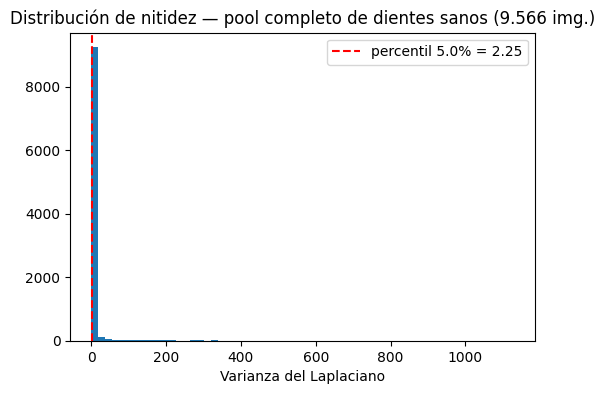

Umbral de blur adoptado (percentil 5.0% del pool completo): 2.25

Pasan filtro de calidad completo (resolución + nitidez): 9087 / 9566 (95.0%)

Distribución de imágenes aptas por vista:
  Lower Front         : 880 aptas de 926 disponibles (95.0%)
  Lower Left          : 1401 aptas de 1566 disponibles (89.5%)
  Lower Occlusal      : 1022 aptas de 1026 disponibles (99.6%)
  Lower Right         : 1279 aptas de 1401 disponibles (91.3%)
  Upper Front         : 1028 aptas de 1075 disponibles (95.6%)
  Upper Left          : 1237 aptas de 1289 disponibles (96.0%)
  Upper Occlusal      : 1122 aptas de 1140 disponibles (98.4%)
  Upper Right         : 1118 aptas de 1143 disponibles (97.8%)


In [ ]:
def blur_variance(image: np.ndarray) -> float:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

if QUALITY_CACHE_PATH.exists():
    print(f"Cargando cache existente: {QUALITY_CACHE_PATH}")
    df_pool = pd.read_csv(QUALITY_CACHE_PATH)
else:
    print("No hay cache. Calculando resolución y nitidez sobre el pool completo "
          f"({total_disponibles} imágenes)... esto toma 1-3 min.")
    filas = []
    for view, imgs in inventario.items():
        for img_path in imgs:
            img = cv2.imread(str(img_path))
            if img is None:
                filas.append({"view": view, "path": str(img_path), "stem": img_path.stem,
                              "width": None, "height": None, "blur_var": None,
                              "legible": False})
                continue
            h, w = img.shape[:2]
            filas.append({
                "view": view, "path": str(img_path), "stem": img_path.stem,
                "width": w, "height": h,
                "blur_var": blur_variance(img),
                "legible": True,
            })
    df_pool = pd.DataFrame(filas)
    df_pool.to_csv(QUALITY_CACHE_PATH, index=False)
    print(f"Cache guardada en: {QUALITY_CACHE_PATH}")

print(f"\nTotal en cache: {len(df_pool)} imágenes")
print(f"No legibles: {(~df_pool['legible']).sum()}")

# Filtro de resolución mínima
df_pool["pasa_resolucion"] = (
    df_pool["legible"]
    & (df_pool["width"] >= MIN_WIDTH)
    & (df_pool["height"] >= MIN_HEIGHT)
)
n_pasa_resolucion = df_pool["pasa_resolucion"].sum()
print(f"Pasan resolución mínima ({MIN_WIDTH}x{MIN_HEIGHT}): {n_pasa_resolucion} / "
      f"descartadas: {len(df_pool) - n_pasa_resolucion}")

# Umbral de nitidez calculado SOLO sobre las que ya pasaron resolución,
# y SOLO sobre este pool (sin mezclar con el umbral usado en el dataset de caries).
blur_values_pool = df_pool.loc[df_pool["pasa_resolucion"], "blur_var"].to_numpy()

plt.figure(figsize=(6, 4))
plt.hist(blur_values_pool, bins=60)
blur_threshold = float(np.percentile(blur_values_pool, BLUR_PERCENTILE))
plt.axvline(blur_threshold, color="red", linestyle="--",
            label=f"percentil {BLUR_PERCENTILE}% = {blur_threshold:.2f}")
plt.title("Distribución de nitidez — pool completo de dientes sanos (9.566 img.)")
plt.xlabel("Varianza del Laplaciano")
plt.legend()
plt.show()

print(f"Umbral de blur adoptado (percentil {BLUR_PERCENTILE}% del pool completo): {blur_threshold:.2f}")

df_pool["pasa_nitidez"] = df_pool["pasa_resolucion"] & (df_pool["blur_var"] >= blur_threshold)
df_pool["pasa_calidad"] = df_pool["pasa_nitidez"]

n_pasa_calidad = df_pool["pasa_calidad"].sum()
print(f"\nPasan filtro de calidad completo (resolución + nitidez): {n_pasa_calidad} / "
      f"{len(df_pool)} ({n_pasa_calidad/len(df_pool):.1%})")

print("\nDistribución de imágenes aptas por vista:")
resumen_calidad_vista = df_pool[df_pool["pasa_calidad"]].groupby("view").size()
for view in VIEWS_HEALTHY:
    disponibles = len(inventario[view])
    aptas = int(resumen_calidad_vista.get(view, 0))
    print(f"  {view:20s}: {aptas} aptas de {disponibles} disponibles ({aptas/disponibles:.1%})")

# Pool final desde el que se muestreará (reemplaza a `inventario` para el paso 4)
pool_apto = df_pool[df_pool["pasa_calidad"]].copy()

    ⚠️ Review the graph and table by view: if any view has been
    disproportionately reduced by the filter, document the finding before
    continuing—it may be relevant to the article (section 3.1.2).

## 3. Calculation of the Number of Negatives Required

Use the confirmed ACTUAL numbers from the corrected caries dataset.
Availability is now validated against the **pool already filtered by
quality** (`pool_apto`), not against the raw total.


In [ ]:
N_IMAGENES_CARIES_ACTUAL = 1445     # dataset_caries_corregido: total real
N_NEGATIVOS_YA_EXISTENTES = 36      # 31 (train) + 3 (val) + 2 (test), ya confirmados

n_negativos_necesarios_total = int(round(
    (TARGET_NEGATIVE_RATIO * N_IMAGENES_CARIES_ACTUAL) / (1 - TARGET_NEGATIVE_RATIO)
))
n_negativos_a_agregar = max(0, n_negativos_necesarios_total - N_NEGATIVOS_YA_EXISTENTES)

print(f"Ratio objetivo de negativos: {TARGET_NEGATIVE_RATIO:.0%}")
print(f"Negativos totales necesarios para ese ratio: {n_negativos_necesarios_total}")
print(f"Negativos ya existentes en el dataset de caries corregido: {N_NEGATIVOS_YA_EXISTENTES}")
print(f"Negativos A AGREGAR desde el dataset de dientes sanos: {n_negativos_a_agregar}")
print(f"Dataset final combinado (aprox.): "
      f"{N_IMAGENES_CARIES_ACTUAL + n_negativos_a_agregar} imágenes, "
      f"de las cuales {n_negativos_necesarios_total} serían negativas "
      f"({n_negativos_necesarios_total/(N_IMAGENES_CARIES_ACTUAL + n_negativos_a_agregar):.1%})")

total_apto = len(pool_apto)
if n_negativos_a_agregar > total_apto:
    print(f"\n⚠️ El pool APTO (tras filtro de calidad) tiene {total_apto} imágenes disponibles, "
          f"insuficientes para los {n_negativos_a_agregar} requeridos. Se usará el máximo disponible.")
    n_negativos_a_agregar = total_apto

Ratio objetivo de negativos: 15%
Negativos totales necesarios para ese ratio: 255
Negativos ya existentes en el dataset de caries corregido: 36
Negativos A AGREGAR desde el dataset de dientes sanos: 219
Dataset final combinado (aprox.): 1664 imágenes, de las cuales 255 serían negativas (15.3%)


## 4. Muestreo estratificado proporcional a las 8 vistas (desde el pool APTO)

Diferencia clave respecto de la versión anterior: se muestrea desde
`pool_apto` (ya filtrado por calidad), así que todo lo seleccionado aquí
pasa automáticamente el filtro — ya no hay riesgo de que la muestra se
quede corta al filtrar después.


In [ ]:
pool_por_vista = {
    view: [Path(p) for p in pool_apto.loc[pool_apto["view"] == view, "path"]]
    for view in VIEWS_HEALTHY
}

seleccionados = []
proporcion_por_vista = {v: len(imgs) / total_apto for v, imgs in pool_por_vista.items()}

restante = n_negativos_a_agregar
vistas_ordenadas = sorted(pool_por_vista.items(), key=lambda kv: len(kv[1]))
for i, (view, imgs) in enumerate(vistas_ordenadas):
    if i == len(vistas_ordenadas) - 1:
        n_tomar = restante
    else:
        n_tomar = min(len(imgs), int(round(n_negativos_a_agregar * proporcion_por_vista[view])))
    n_tomar = min(n_tomar, len(imgs))
    muestra = random.sample(imgs, k=n_tomar)
    seleccionados.extend([(view, p) for p in muestra])
    restante -= n_tomar

print(f"Total seleccionado: {len(seleccionados)} imágenes (todas ya pasaron el filtro de calidad)")
resumen_vista = Counter(v for v, _ in seleccionados)
for view in VIEWS_HEALTHY:
    print(f"  {view:20s}: {resumen_vista.get(view, 0)} seleccionadas de "
          f"{len(pool_por_vista[view])} aptas ({len(inventario[view])} totales)")

Total seleccionado: 219 imágenes (todas ya pasaron el filtro de calidad)
  Lower Front         : 21 seleccionadas de 880 aptas (926 totales)
  Lower Left          : 33 seleccionadas de 1401 aptas (1566 totales)
  Lower Occlusal      : 25 seleccionadas de 1022 aptas (1026 totales)
  Lower Right         : 31 seleccionadas de 1279 aptas (1401 totales)
  Upper Front         : 25 seleccionadas de 1028 aptas (1075 totales)
  Upper Left          : 30 seleccionadas de 1237 aptas (1289 totales)
  Upper Occlusal      : 27 seleccionadas de 1122 aptas (1140 totales)
  Upper Right         : 27 seleccionadas de 1118 aptas (1143 totales)


## 5. Cluster Detection (Patient/Session) to Prevent Data Leakage

The Mendeley dataset (Chaudhary et al., 2024) does not explicitly document
multiple acquisitions per patient in the filename. The actual pattern is examined
before assuming independence.


In [ ]:
records = [{"view": view, "image_path": img_path, "stem": img_path.stem}
           for view, img_path in seleccionados]

muestra_nombres = [r["stem"] for r in records[:20]]
print("Ejemplos de nombres de archivo para inspección manual del patrón:")
for n in muestra_nombres:
    print(" -", n)

patron_id = re.compile(r"(\d{3,})")

def extraer_grupo(stem: str) -> str:
    match = patron_id.search(stem)
    return match.group(1) if match else stem

grupos_detectados = Counter(extraer_grupo(r["stem"]) for r in records)
n_grupos_con_repeticion = sum(1 for g, n in grupos_detectados.items() if n > 1)
print(f"\nGrupos únicos detectados: {len(grupos_detectados)}")
print(f"Grupos con más de una imagen (posible mismo paciente/sesión): {n_grupos_con_repeticion}")
print(">>> Revisa la lista impresa arriba: si el número repetido no corresponde a un ID de")
print(">>> paciente real (ej. coincide con una resolución o timestamp truncado), cambia")
print(">>> `extraer_grupo` para usar `r['stem']` directamente (grupo = imagen independiente).")

Ejemplos de nombres de archivo para inspección manual del patrón:
 - LF 0401
 - LF 0586
 - LF 0043
 - LF 0768
 - LF 0725
 - LF 0670
 - LF 0195
 - LF 0555
 - LF 0895
 - LF 0530
 - LF 0610
 - LF 0047
 - LF 0387
 - LF 0392
 - LF 0421
 - LF 0527
 - LF 0896
 - LF 0014
 - LF 0364
 - LF 0538

Grupos únicos detectados: 201
Grupos con más de una imagen (posible mismo paciente/sesión): 16
>>> Revisa la lista impresa arriba: si el número repetido no corresponde a un ID de
>>> paciente real (ej. coincide con una resolución o timestamp truncado), cambia
>>> `extraer_grupo` para usar `r['stem']` directamente (grupo = imagen independiente).


## 6. Split into train/val/test groups


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

for r in records:
    r["grupo"] = extraer_grupo(r["stem"])

idx_all = np.arange(len(records))
grupos_arr = np.array([r["grupo"] for r in records])

gss1 = GroupShuffleSplit(n_splits=1, train_size=SPLIT_RATIOS["train"], random_state=SEED)
train_idx, temp_idx = next(gss1.split(idx_all, groups=grupos_arr))

val_frac_de_temp = SPLIT_RATIOS["val"] / (SPLIT_RATIOS["val"] + SPLIT_RATIOS["test"])
gss2 = GroupShuffleSplit(n_splits=1, train_size=val_frac_de_temp, random_state=SEED)
temp_grupos_arr = grupos_arr[temp_idx]
val_idx_rel, test_idx_rel = next(gss2.split(temp_idx, groups=temp_grupos_arr))
val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

for i in train_idx:
    records[i]["split"] = "train"
for i in val_idx:
    records[i]["split"] = "val"
for i in test_idx:
    records[i]["split"] = "test"

grupos_train = {records[i]["grupo"] for i in train_idx}
grupos_val = {records[i]["grupo"] for i in val_idx}
grupos_test = {records[i]["grupo"] for i in test_idx}

print("--- Verificación de partición por grupos (negativos) ---")
print(f"Identificadores en train: {len(grupos_train)}")
print(f"Identificadores en val:   {len(grupos_val)}")
print(f"Identificadores en test:  {len(grupos_test)}")
print(f"Coincidencias train–val:  {len(grupos_train & grupos_val)}")
print(f"Coincidencias train–test: {len(grupos_train & grupos_test)}")
print(f"Coincidencias val–test:   {len(grupos_val & grupos_test)}")

print("\nDistribución final por split:")
for split_name in ["train", "val", "test"]:
    n = sum(1 for r in records if r["split"] == split_name)
    print(f"  {split_name}: {n} imágenes negativas")

quality_ok = records  # alias para mantener compatibilidad con las secciones siguientes

--- Verificación de partición por grupos (negativos) ---
Identificadores en train: 140
Identificadores en val:   30
Identificadores en test:  31
Coincidencias train–val:  0
Coincidencias train–test: 0
Coincidencias val–test:   0

Distribución final por split:
  train: 152 imágenes negativas
  val: 31 imágenes negativas
  test: 36 imágenes negativas


## 7. Preprocessing — same functions as the caries dataset

Functions identical to those in `Tratado_1_dataset_Ahmed_tratado.md`, with no
modifications, to maintain consistency between positives and negatives.


In [ ]:
def _odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def op_white_balance(image, method="shades_of_gray", percentile=95.0,
                      shades_p=4.0, saturation_threshold=0.98):
    img_f = image.astype(np.float64)
    norms = []
    for c in range(3):
        ch = img_f[:, :, c].ravel()
        ch = ch[ch > 1e-3]
        norms.append(1.0 if len(ch) == 0 else float((np.mean(ch ** shades_p)) ** (1.0 / shades_p)))
    mean_norm = float(np.mean(norms))
    result = img_f.copy()
    for c in range(3):
        n = norms[c] if norms[c] > 0 else 1.0
        result[:, :, c] = np.clip(img_f[:, :, c] * (mean_norm / n), 0.0, 255.0)
    return result.astype(np.uint8)

def op_clahe(image, color_space="LAB", clip_limit=2.0, tile_grid_size=8, kernel_size=0):
    tile = (int(tile_grid_size[0]), int(tile_grid_size[-1])) if isinstance(tile_grid_size, (list, tuple)) \
        else (int(tile_grid_size), int(tile_grid_size))
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    if color_space.upper() == "LAB":
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        return cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)
    elif color_space.upper() == "HSV":
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        return cv2.cvtColor(cv2.merge([h, s, clahe.apply(v)]), cv2.COLOR_HSV2BGR)
    else:
        channels = list(cv2.split(image))
        return cv2.merge([clahe.apply(c) for c in channels])

def op_specular_highlight(image, method="attenuate", value_threshold=245,
                           saturation_threshold=60, dilate=8, inpaint_radius=8, attenuation=0.7):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    rgb_peak = image.max(axis=2)
    mask = (((hsv[:, :, 2] >= value_threshold) & (hsv[:, :, 1] <= saturation_threshold)) |
            (rgb_peak >= value_threshold)).astype(np.uint8)
    if dilate > 0:
        k = _odd(dilate)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        mask = cv2.dilate(mask, kernel, iterations=1)
    if method == "inpaint":
        return cv2.inpaint(image, mask, inpaint_radius, cv2.INPAINT_TELEA)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    L, a_ch, b_ch = cv2.split(lab)
    L_f = L.astype(np.float32)
    sigma = float(_odd(dilate))
    L_blur = cv2.GaussianBlur(L_f, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
    alpha = mask.astype(np.float32) * attenuation
    L_new = np.clip(L_f * (1.0 - alpha) + L_blur * alpha, 0, 255).astype(np.uint8)
    return cv2.cvtColor(cv2.merge([L_new, a_ch, b_ch]), cv2.COLOR_LAB2BGR)

def op_edges(image, method="laplacian", kernel_size=7, threshold1=83, threshold2=163,
             strength=0.05, overlay=True):
    ksize_odd = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (ksize_odd, ksize_odd), 0)
    if method == "laplacian":
        lap_ksize = min(ksize_odd, 7)
        lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=lap_ksize)
        edge = np.abs(lap)
        norm = np.zeros_like(edge)
        cv2.normalize(edge, norm, 0, 255, cv2.NORM_MINMAX)
        edge = norm.astype(np.uint8)
    else:
        edge = cv2.Canny(blurred, threshold1, threshold2)
    if not overlay:
        return cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
    edge_bgr = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR).astype(np.float32)
    result = image.astype(np.float32) + strength * edge_bgr
    return np.clip(result, 0, 255).astype(np.uint8)

def op_denoise(image, method="median_blur", kernel_size=3, diameter=7, sigma_color=120,
                sigma_space=120, h=6.5, template_window=7, search_window=21,
                guided_radius=8, guided_eps=0.02):
    ksize = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    if method == "median_blur":
        return cv2.medianBlur(image, ksize)
    elif method == "bilateral":
        return cv2.bilateralFilter(image, d=diameter, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    elif method == "nlm":
        return cv2.fastNlMeansDenoisingColored(image, None, h=h, hColor=h,
                                                templateWindowSize=template_window, searchWindowSize=search_window)
    elif method == "gaussian":
        return cv2.GaussianBlur(image, (ksize, ksize), 0)
    return image

def op_brightness_contrast(image, brightness=0, contrast=1.0):
    return cv2.convertScaleAbs(image, alpha=contrast, beta=brightness)

_OP_MAP = {
    "white_balance": op_white_balance,
    "clahe": op_clahe,
    "specular_highlight": op_specular_highlight,
    "edges": op_edges,
    "denoise": op_denoise,
    "brightness_contrast": op_brightness_contrast,
}

def apply_pipeline(image, pipeline):
    result = image.copy()
    for step in pipeline:
        op_name = step["op"]
        params = {k: v for k, v in step.items() if k != "op"}
        fn = _OP_MAP.get(op_name)
        if fn is None:
            raise ValueError(f"Operación no reconocida: '{op_name}'")
        result = fn(result, **params)
    return result

PREPROCESSING_PIPELINE = [
    {"op": "white_balance", "method": "shades_of_gray", "percentile": 95.0,
     "shades_p": 4.0, "saturation_threshold": 0.98},
    {"op": "clahe", "color_space": "LAB", "clip_limit": 1.3,
     "tile_grid_size": [8, 8], "kernel_size": 31},
    {"op": "specular_highlight", "method": "attenuate", "value_threshold": 245,
     "saturation_threshold": 60, "dilate": 8, "inpaint_radius": 8, "attenuation": 0.7},
    {"op": "edges", "method": "laplacian", "kernel_size": 7, "threshold1": 83,
     "threshold2": 163, "strength": 0.05, "overlay": True},
    {"op": "denoise", "method": "median_blur", "kernel_size": 3},
    {"op": "brightness_contrast", "brightness": -5, "contrast": 1.0},
]

print("Pipeline de preprocesamiento cargado (idéntico al del dataset de caries):")
for step in PREPROCESSING_PIPELINE:
    print(f"  [{step['op']}]")

Pipeline de preprocesamiento cargado (idéntico al del dataset de caries):
  [white_balance]
  [clahe]
  [specular_highlight]
  [edges]
  [denoise]
  [brightness_contrast]


## 8. Generating Preprocessed Images + Empty YOLO Labels


In [ ]:
NEG_YOLO_ROOT = RUNTIME_ROOT / "negativos_yolo"
for split in ["train", "val", "test"]:
    (NEG_YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (NEG_YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

for r in quality_ok:
    img = cv2.imread(str(r["image_path"]))
    processed = apply_pipeline(img, PREPROCESSING_PIPELINE)

    vista_norm = r["view"].replace(" ", "_")
    out_name = f"healthy_{vista_norm}_{r['stem']}"

    out_img_path = NEG_YOLO_ROOT / "images" / r["split"] / f"{out_name}{r['image_path'].suffix.lower()}"
    out_lbl_path = NEG_YOLO_ROOT / "labels" / r["split"] / f"{out_name}.txt"

    cv2.imwrite(str(out_img_path), processed)
    out_lbl_path.touch()  # archivo de etiqueta VACÍO -> imagen negativa válida

    r["processed_path"] = out_img_path
    r["label_path"] = out_lbl_path

print("Imágenes negativas preprocesadas y exportadas:", len(quality_ok))
for split_name in ["train", "val", "test"]:
    n = sum(1 for r in quality_ok if r["split"] == split_name)
    print(f"  {split_name}: {n} imágenes negativas")

Imágenes negativas preprocesadas y exportadas: 219
  train: 152 imágenes negativas
  val: 31 imágenes negativas
  test: 36 imágenes negativas


## 8b. Before-and-after visual display


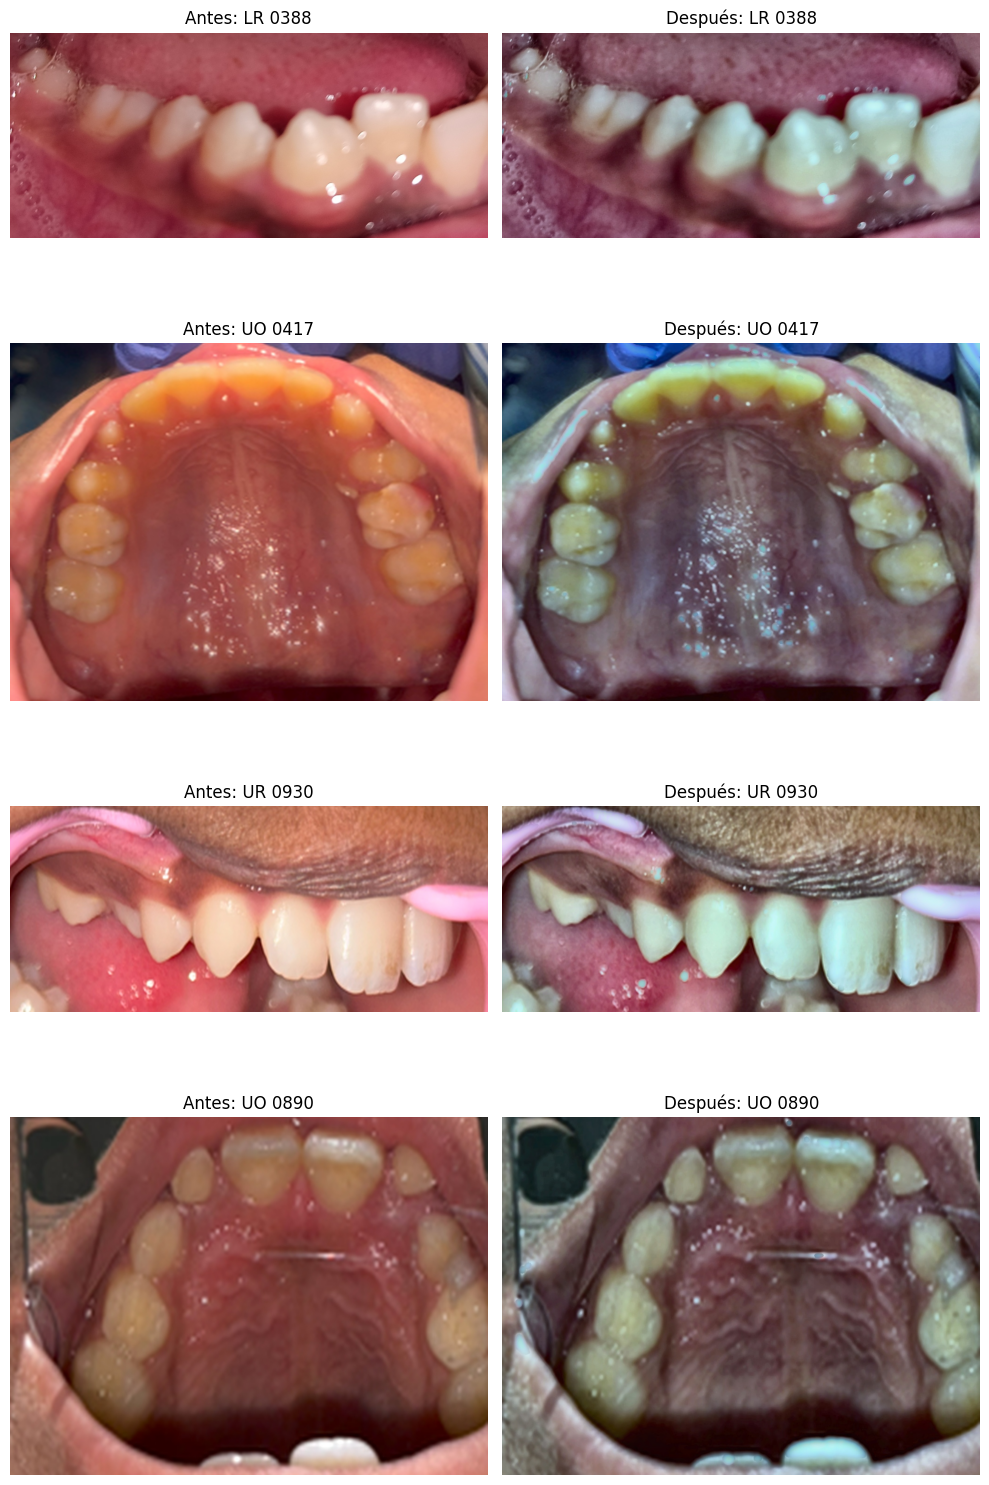

In [ ]:
sample_recs = random.sample(quality_ok, k=min(4, len(quality_ok)))
fig, axes = plt.subplots(len(sample_recs), 2, figsize=(10, 4 * len(sample_recs)))
if len(sample_recs) == 1:
    axes = [axes]
for row, rec in zip(axes, sample_recs):
    before = cv2.cvtColor(cv2.imread(str(rec["image_path"])), cv2.COLOR_BGR2RGB)
    after = cv2.cvtColor(cv2.imread(str(rec["processed_path"])), cv2.COLOR_BGR2RGB)
    row[0].imshow(before); row[0].set_title(f"Antes: {rec['stem']}"); row[0].axis("off")
    row[1].imshow(after); row[1].set_title(f"Después: {rec['stem']}"); row[1].axis("off")
plt.tight_layout()
plt.show()

## 9. Merging with the corrected caries dataset and combined statistics

Read directly from `dataset_caries_corregido/` (folder, already generated
by `Tratado_2_dataset_Ahmed.ipynb`), without needing to unzip it.


In [ ]:
MERGED_ROOT = RUNTIME_ROOT / "dataset_final"
for split in ["train", "val", "test"]:
    (MERGED_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# 9.1 Copiar negativos generados (dientes sanos)
for split in ["train", "val", "test"]:
    for img_p in (NEG_YOLO_ROOT / "images" / split).iterdir():
        shutil.copy(img_p, MERGED_ROOT / "images" / split / img_p.name)
    for lbl_p in (NEG_YOLO_ROOT / "labels" / split).iterdir():
        shutil.copy(lbl_p, MERGED_ROOT / "labels" / split / lbl_p.name)

# 9.2 Copiar el dataset de caries corregido
for split in ["train", "val", "test"]:
    img_dir = CARIES_ROOT_CORREGIDO / "images" / split
    lbl_dir = CARIES_ROOT_CORREGIDO / "labels" / split
    for img_p in img_dir.glob("*"):
        shutil.copy(img_p, MERGED_ROOT / "images" / split / img_p.name)
    for lbl_p in lbl_dir.glob("*"):
        shutil.copy(lbl_p, MERGED_ROOT / "labels" / split / lbl_p.name)

print("Dataset de caries corregido fusionado desde:", CARIES_ROOT_CORREGIDO)

# 9.3 data.yaml
data_yaml_content = f"""train: images/train
val: images/val
test: images/test

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
(MERGED_ROOT / "data.yaml").write_text(data_yaml_content)

# 9.4 Estadística final combinada
print("\n--- ESTADÍSTICA FINAL DEL DATASET COMBINADO (caries corregido + negativos) ---")
total_img_final, total_ann_final, total_neg_final = 0, 0, 0
for split in ["train", "val", "test"]:
    imgs = list((MERGED_ROOT / "images" / split).glob("*"))
    n_img = len(imgs)
    n_ann = 0
    n_neg = 0
    for img_p in imgs:
        lbl_p = MERGED_ROOT / "labels" / split / f"{img_p.stem}.txt"
        if lbl_p.exists():
            with open(lbl_p) as f:
                lineas = [l for l in f if l.strip()]
            n_ann += len(lineas)
            if len(lineas) == 0:
                n_neg += 1
    if n_img:
        print(f"{split.upper()}: {n_img} imágenes, {n_ann} cajas, {n_neg} negativas ({n_neg/n_img:.1%} del split)")
    else:
        print(f"{split.upper()}: 0 imágenes")
    total_img_final += n_img
    total_ann_final += n_ann
    total_neg_final += n_neg

if total_img_final:
    print(f"\nTOTAL: {total_img_final} imágenes, {total_ann_final} cajas, "
          f"{total_neg_final} negativas ({total_neg_final/total_img_final:.1%} del dataset)")

Dataset de caries corregido fusionado desde: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 2

--- ESTADÍSTICA FINAL DEL DATASET COMBINADO (caries corregido + negativos) ---
TRAIN: 1180 imágenes, 3189 cajas, 183 negativas (15.5% del split)
VAL: 242 imágenes, 687 cajas, 34 negativas (14.0% del split)
TEST: 242 imágenes, 693 cajas, 38 negativas (15.7% del split)

TOTAL: 1664 imágenes, 4569 cajas, 255 negativas (15.3% del dataset)


## 10. Verifying Group Integrity in the Combined Dataset

Confirm that the merge did not introduce leakage: the caries groups (train 702 /
val 151 / test 151) and the negative groups must continue to show no overlap
across partitions after the combined copy.


In [ ]:
def grupo_de_archivo(nombre: str) -> str:
    m = re.compile(r"(\d{3}[-_]\d{3}[-_]\d+[-_]\d{2})").search(nombre)
    if m:
        return re.sub(r"[-_]", "-", m.group(1))
    m2 = re.compile(r"(\d{3,})").search(nombre)
    return m2.group(1) if m2 else nombre

grupos_por_split = {"train": set(), "val": set(), "test": set()}
for split in ["train", "val", "test"]:
    for img_p in (MERGED_ROOT / "images" / split).iterdir():
        grupos_por_split[split].add(grupo_de_archivo(img_p.stem))

print("--- Verificación de integridad de grupos tras la fusión ---")
print(f"Coincidencias train–val:  {len(grupos_por_split['train'] & grupos_por_split['val'])}")
print(f"Coincidencias train–test: {len(grupos_por_split['train'] & grupos_por_split['test'])}")
print(f"Coincidencias val–test:   {len(grupos_por_split['val'] & grupos_por_split['test'])}")

--- Verificación de integridad de grupos tras la fusión ---
Coincidencias train–val:  0
Coincidencias train–test: 0
Coincidencias val–test:   0


## 11. Saved to Drive (direct folder, no zip file)


In [ ]:
if OUTPUT_ROOT_DRIVE.exists():
    shutil.rmtree(OUTPUT_ROOT_DRIVE)
shutil.copytree(MERGED_ROOT, OUTPUT_ROOT_DRIVE)
print("Dataset combinado exportado a:", OUTPUT_ROOT_DRIVE)

Dataset combinado exportado a: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/Dataset-Caries-Balanceado
